# Phân Tích Thực Nghiệm (RBL-4)

**Mô hình:** Claude 3.5 Sonnet (Few-shot)
**Dữ liệu:** `fewshot_sonnet5_summary.csv`

*Ghi chú: Dựa trên bản Amendment 01, nhóm quyết định (1) Bổ sung metric `skeleton_cosine` thay cho `raw_cosine` do `raw_cosine` không đạt ngưỡng 0.85, và (2) Đổi mô hình sang Claude 3.5 Sonnet do GPT-4o few-shot có median skeleton_cosine = 0.8356 (vẫn chưa đạt 0.85).*

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.stats import binomtest

sns.set_theme(style="whitegrid")
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

## 1. Tải Dữ Liệu

In [37]:
csv_path = r"fewshot/claude-sonnet-5/fewshot_sonnet5_summary.csv"
df = pd.read_csv(csv_path)
print(f"Tổng số mẫu dữ liệu: {len(df)}")
df.head()

Tổng số mẫu dữ liệu: 100


,id,raw_cosine,skeleton_cosine,executable
0,1,0.9027,1.0000,PASS
1,2,0.7452,0.8443,PASS
2,3,0.8164,0.9208,PASS
3,4,0.7188,0.8744,PASS
4,5,0.6779,0.9128,PASS


## 2. Thống Kê Mô Tả (Descriptive Statistics)

In [38]:
desc = df[['raw_cosine', 'skeleton_cosine']].describe()
display(desc)

,raw_cosine,skeleton_cosine
count,100.000000,100.000000
mean,0.714644,0.812994
std,0.188774,0.201901
min,0.000000,0.000000
25%,0.702650,0.794175
50%,0.761650,0.862900
75%,0.810550,0.907500
max,0.908800,1.000000


## 3. Figure 1 — Distribution Plot (Metric chính: Skeleton Cosine)

Histogram kết hợp boxplot phía trên để thể hiện phân phối metric chính.
Đáp ứng yêu cầu RBL-4 §8.4: title, axis labels, N annotation, ≥ 300 DPI.

C:\Users\hoang\AppData\Local\Temp\ipykernel_5388\2319983447.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


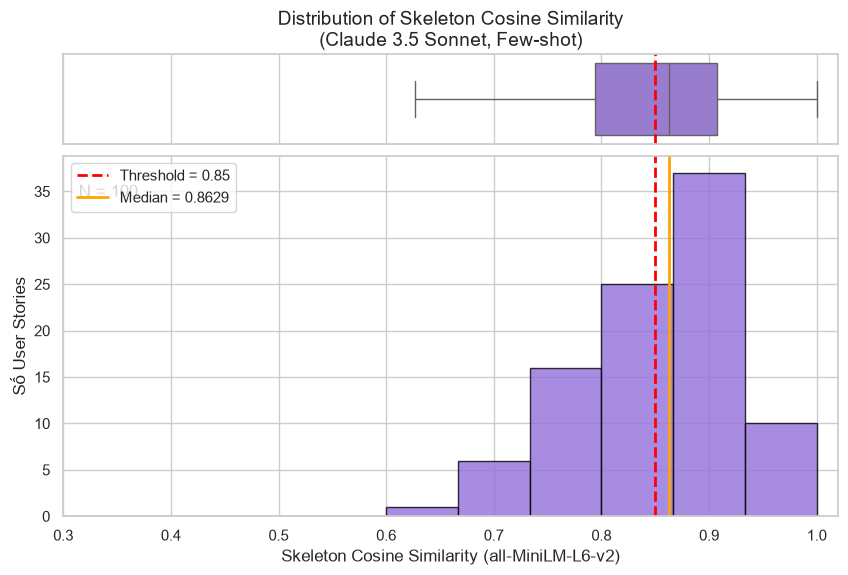

Saved: figures/fig1_distribution.png


In [39]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6),
                                       sharex=True,
                                       gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.05})

# Boxplot phía trên
sns.boxplot(x=df['skeleton_cosine'], color='mediumpurple', ax=ax_box)
ax_box.axvline(0.85, color='red', linestyle='--', linewidth=2)
ax_box.set_yticks([])
ax_box.set_title('Distribution of Skeleton Cosine Similarity\n(Claude 3.5 Sonnet, Few-shot)', fontsize=14)

# Histogram phía dưới
ax_hist.hist(df['skeleton_cosine'], bins=15, color='mediumpurple', edgecolor='black', alpha=0.8)
ax_hist.axvline(0.85, color='red', linestyle='--', linewidth=2, label='Threshold = 0.85')
median_val = df['skeleton_cosine'].median()
ax_hist.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median = {median_val:.4f}')
ax_hist.set_xlabel('Skeleton Cosine Similarity (all-MiniLM-L6-v2)', fontsize=12)
ax_hist.set_ylabel('Số User Stories', fontsize=12)
ax_hist.text(0.02, 0.92, f'N = {len(df)}', transform=ax_hist.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax_hist.legend(loc='upper left', fontsize=11)
ax_hist.set_xlim(0.3, 1.02)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig1_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig1_distribution.png')

## 4. Figure 2 — Comparison Plot (RQ2: Executable Rate)

So sánh tỷ lệ PASS/FAIL với ngưỡng kỳ vọng 80%.
Đáp ứng yêu cầu RBL-4 §8.4: title, axis labels, N annotation, ≥ 300 DPI.

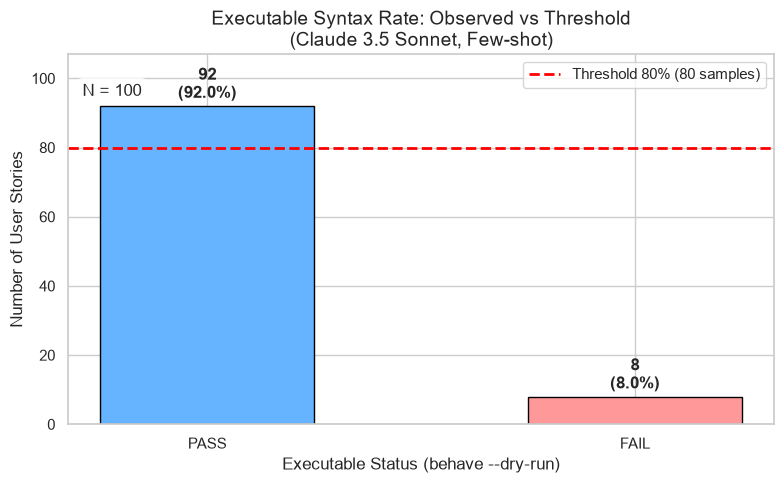

Saved: figures/fig2_comparison.png


In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
exec_counts = df['executable'].value_counts()
bars = ax.bar(exec_counts.index, exec_counts.values, color=['#66b3ff', '#ff9999'], edgecolor='black', width=0.5)
ax.axhline(y=len(df)*0.80, color='red', linestyle='--', linewidth=2, label=f'Threshold 80% ({int(len(df)*0.80)} samples)')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Executable Syntax Rate: Observed vs Threshold\n(Claude 3.5 Sonnet, Few-shot)', fontsize=14)
ax.set_xlabel('Executable Status (behave --dry-run)')
ax.set_ylabel('Number of User Stories')
ax.text(0.02, 0.92, f'N = {len(df)}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(loc='upper right')
ax.set_ylim(0, max(exec_counts.values) + 15)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig2_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig2_comparison.png')

## 5. Kiểm Định Giả Thuyết (Hypothesis Testing)

### RQ1: Semantic Similarity (Skeleton Cosine)
- $H_0^{(1)}: \mu_{sim} \leq 0.85$
- $H_1^{(1)}: \mu_{sim} > 0.85$
- **Kiểm định:** One-sample Wilcoxon signed-rank test (one-tailed, $\alpha = 0.05$)

In [41]:
stat, p_val = wilcoxon(df['skeleton_cosine'] - 0.85, alternative='greater')
print(f"Wilcoxon Statistic: {stat}")
print(f"P-value: {p_val:.6f}")

alpha = 0.05
if p_val < alpha:
    print("\n=> KẾT LUẬN: Reject H0. Có đủ bằng chứng thống kê (p < 0.05) để khẳng định mô hình đạt skeleton_cosine > 0.85.")
else:
    print("\n=> KẾT LUẬN: Fail to reject H0. KHÔNG đủ bằng chứng thống kê để khẳng định mô hình đạt skeleton_cosine > 0.85.")

Wilcoxon Statistic: 2600.0
P-value: 0.398250

=> KẾT LUẬN: Fail to reject H0. KHÔNG đủ bằng chứng thống kê để khẳng định mô hình đạt skeleton_cosine > 0.85.


### RQ2: Executable Rate
- $H_0^{(2)}: p_{exec} \leq 0.80$
- $H_1^{(2)}: p_{exec} > 0.80$
- **Kiểm định:** Exact Binomial Test (one-tailed, $\alpha = 0.05$)

In [42]:
k = len(df[df['executable'] == 'PASS'])
n = len(df)
res = binomtest(k, n, p=0.80, alternative='greater')
print(f"Số lượng PASS: {k}/{n} ({k/n:.2%})")
print(f"P-value: {res.pvalue:.6f}")

if res.pvalue < alpha:
    print("\n=> KẾT LUẬN: Reject H0. Có đủ bằng chứng thống kê để khẳng định executable rate > 80%.")
else:
    print("\n=> KẾT LUẬN: Fail to reject H0. KHÔNG đủ bằng chứng thống kê để khẳng định executable rate > 80%.")

Số lượng PASS: 92/100 (92.00%)
P-value: 0.000855

=> KẾT LUẬN: Reject H0. Có đủ bằng chứng thống kê để khẳng định executable rate > 80%.
